# Cellpose in Python

<div class="custom-button-row">
    <a 
        class="custom-button custom-download-button" href="../../../notebooks/05_segmentation/deep_learning/cellpose_notebook.ipynb" download>
        <i class="fas fa-download"></i> Download this Notebook
    </a>
    <a
    class="custom-button custom-download-button" href="https://colab.research.google.com/github/bobiac/bobiac-book/blob/gh-pages/colab_notebooks/05_segmentation/deep_learning/cellpose_notebook_colab.ipynb" target="_blank">
        <img class="button-icon" src="../../../_static/logo/icon-google-colab.svg" alt="Open in Colab">
        Open in Colab
    </a>
</div>

In [1]:
# /// script
# requires-python = ">=3.12"
# dependencies = [
#     "matplotlib",
#     "cellpose",
#     "tqdm",
#     "ndv[jupyter,pygfx]",
#     "jupyter-rfb<=0.5.4",
# ]
# ///

## Overview

[Website](https://www.cellpose.org) | [GitHub](https://github.com/mouseland/cellpose) | [Paper](https://www.biorxiv.org/content/10.1101/2025.04.28.651001v1) | [Cellpose Documentation](https://cellpose.readthedocs.io/en/latest/index.html) | [Cellpose API](https://cellpose.readthedocs.io/en/latest/api.html#)

In this section, we'll learn how to use `Cellpose`, a powerful deep learning tool for cell segmentation, works on a wide variety of microscopy images and doesn't require retraining for many common use cases.

In this notebook, we'll see how to run `Cellpose` on single images or on a folder of images, and how to visualize and save the results.

The images we will use for this section can be downloaded from the <a href="https://bobiac.github.io/bobiac-book/_static/data/05_segmentation_cellpose.zip" download> <i class="fas fa-download"></i> Cellpose Dataset</a>.

<p class="alert alert-warning">
    <strong>💡 Tip:</strong> <code>Cellpose</code> runs significantly faster on a GPU. It supports both NVIDIA GPUs (CUDA) and Apple Silicon (MPS). If you don't have either, we recommend running this notebook on <a href="https://colab.research.google.com/github/bobiac/bobiac-book/blob/gh-pages/colab_notebooks/05_segmentation/deep_learning/cellpose_notebook_colab.ipynb" target="_blank"> Google Colab</a> for faster performance.
</p>

<details>
<summary><b>NVIDIA GPU (CUDA - Windows/Linux)</b></summary>
<br>

In order to use `Cellpose` in this notebook with an NVIDIA GPU:
1. you need to have the [NVIDIA drivers](https://www.nvidia.com/en-us/drivers/) installed on your system.
2. you can run `nvidia-smi` in the terminal to check your CUDA version (shown in the top-right of the output, e.g. `CUDA Version: 13.0.0`).
3. update the `# /// script` block at the top of this notebook to install the appropriate version of [PyTorch with CUDA support](https://pytorch.org/get-started/locally/) (replace `cu130` with your CUDA version):

```python
    # /// script
    # requires-python = ">=3.12"
    # dependencies = [
    #     "matplotlib",
    #     "cellpose",
    #     "tqdm",
    #     "torch",
    #     "torchvision",
    # ]
    #
    # [tool.uv.sources]
    # torch = { index = "pytorch-cu130" }
    # torchvision = { index = "pytorch-cu130" }
    #
    # [[tool.uv.index]]
    # name = "pytorch-cu130"
    # url = "https://download.pytorch.org/whl/cu130"
    # explicit = true
    # ///
```

4. re-run the notebook using `uvx juv run`.
</details>

## Import Libraries

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import ndv
import numpy as np
from cellpose import core, io, models, plot
from cellpose.models import MODEL_DIR
from tqdm import tqdm

## Setup

In [3]:
io.logger_setup()  # to get printing of progress

use_gpu = core.use_gpu()
print("GPU available:", use_gpu)

[GUI INFO] : WRITING LOG OUTPUT TO /Users/fdrgsp/.cellpose/run.log

cellpose version: 	4.2.1.1 
platform:       	darwin 
python version: 	3.13.3 
torch version:  	2.12.1
2026-06-25 11:54:18,795 [io INFO] WRITING LOG OUTPUT TO /Users/fdrgsp/.cellpose/run.log
2026-06-25 11:54:18,796 [io INFO] 
cellpose version: 	4.2.1.1 
platform:       	darwin 
python version: 	3.13.3 
torch version:  	2.12.1
2026-06-25 11:54:18,816 [core INFO] ** TORCH MPS version installed and working. **
GPU available: True


## Run Cellpose on a Single Image

In this section, we’ll apply `Cellpose` to a single image and visualize the segmentation result.

### Load the Image

To load the image, we can use the `imread` method from the `Cellpose` `io` module (or the `tifffile` library if you add it to the dependencies).

In [10]:
image_path = "../../../_static/images/cellpose/cell_cellpose.tif"
image = io.imread(image_path)  # or image = tifffile.imread(image_path)

Let's inspect the image shape. How many channels do we have?

In [11]:
print(image.shape)

(5, 1040, 1392)


We can use the `imshow` method from the `ndv` library (or from the `matplotlib.pyplot` library) to visualize the image.

<p class="alert alert-info">
    <strong>💡 Note:</strong> Since this is a multi-channel image, if using <code>matplotlib</code>, you will need to specify which channel to visualize (e.g. <code>plt.imshow(image[0])</code> for the first channel).
</p>

In [12]:
ndv.imshow(
    image,
    channel_mode="composite",
    luts={
        0: {"cmap": "cyan"},
        1: {"cmap": "magenta"},
        2: {"cmap": "green"},
        3: {"cmap": "yellow"},
        4: {"cmap": "gray"},
    },
)

RFBOutputContext()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
viewer = ndv.imshow(
    image,
    channel_mode="composite",
    luts={
        0: {"cmap": "cyan"},
        1: {"cmap": "magenta"},
        2: {"cmap": "green"},
        3: {"cmap": "yellow"},
        4: {"cmap": "gray"},
    },
)

In [ ]:
viewer.widget().children[1].snapshot()

### Initialize the Model

To initialize `Cellpose` model we can use the `models.CellposeModel()` class.

There are other parameters we can set when initializing the model, here we will only use `pretrained_model` to specify which pretrained model to use and `gpu` to specify whether to use GPU (if available) for faster inference.

Currently, the available pretrained models are:
- `cpsam`: this is the original `CellposeSAM` model released in April 2025 using the `SAM-ViTL` backbone (default model)
- `cpsam_v2`: this is the `CellposeSAM` model released in June 2026 using the `SAM-ViTL` backbone, it includes a fix in the training for low contrast regions
- `cpdino`: this is the `CellposeDINO` model released in June 2026 using the `DINOv3-ViTL` backbone
- `cpdino-vitb`: this is the `CellposeDINO` model released in June 2026 using the `DINOv3-ViTB` backbone (smaller model)

<p class="alert alert alert-info">
    <strong>Note:</strong> Only the default <code>cpsam</code> model is downloaded automatically the first time you run this notebook (this may take a while). The other models (<code>cpsam_v2</code>, <code>cpdino</code>, <code>cpdino-vitb</code>) must be downloaded manually, see below.
</p>

#### Downloading the Other Pretrained Models

These models are hosted on the [Cellpose-SAM Hugging Face repository](https://huggingface.co/mouseland/cellpose-sam). We need to download the model weights and place them in the `~/.cellpose/models` directory (the `MODEL_DIR` variable from the `cellpose.models` module).

In [ ]:
from cellpose.utils import download_url_to_file

model_name = "cpsam_v2"  # or "cpdino" / "cpdino-vitb"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
model_path = MODEL_DIR / model_name
if not model_path.exists():
    url = f"https://huggingface.co/mouseland/cellpose-sam/resolve/main/{model_name}"
    download_url_to_file(url, str(model_path))

Now we can initialize the model with the different pretrained models by setting the `pretrained_model` parameter.

In [7]:
model_path = str(MODEL_DIR / "cpsam_v2")  # or "cpdino" / "cpdino-vitb" or "cpsam"
model = models.CellposeModel(pretrained_model=model_path, gpu=use_gpu)

2026-06-25 11:54:34,192 [core INFO] ** TORCH MPS version installed and working. **
2026-06-25 11:54:34,193 [core INFO] >>>> using GPU (MPS)
2026-06-25 11:54:34,774 [models INFO] >>>> loading model /Users/fdrgsp/.cellpose/models/cpsam_v2


### Run Cellpose

After initializing the model, we can run it on the image using the `model.eval()` method (see dropdown below for parameters details).

We want to run cellpose only on the nuclei and cytoplasm channels (the first two) and not on the spots channels. Therefore, we should pass to the `model.eval()` method only the first two channels of the image (i.e. `image[[0, 1]]`).

<details>
<summary><b>Cellpose <code>model.eval()</code> Parameters</b></summary>
<br>

<pre><code>model.eval(
    x,
    channel_axis=None,
    normalize=True,
    invert=False,
    diameter=None,
    flow_threshold=0.4,
    cellprob_threshold=0.0,
    min_size=15,
    max_size_fraction=0.4,
    niter=None,
    compute_masks=True,
    batch_size=8,
    resample=True,
    bsize=256,
    tile_overlap=0.1,
    augment=False,
    do_3D=False,
    z_axis=None,
    anisotropy=None,
    flow3D_smooth=0,
    stitch_threshold=0.0,
)</code></pre>

**Input**

| Parameter | Default | Description |
|:---|:---|:---|
| `x` | — | A single image or list of images (2D/3D/4D). For `cpsam`, up to 3 channels are used. |
| `channel_axis` | `None` | Which axis of `x` is the channel axis. If `None`, Cellpose auto-detects it. |

**Preprocessing**

| Parameter | Default | Description |
|:---|:---|:---|
| `normalize` | `True` | Normalize intensities to 0–1 using 1st/99th percentile. Pass `False` to skip, or a dict for fine-grained control (see below). |
| `invert` | `False` | Invert pixel intensities before running the network. Useful for brightfield images where cells are dark on a bright background. |
| `diameter` | `None` | Expected cell diameter in pixels. Used to rescale the image so cells appear ~30 px wide to the model. If `None`, no rescaling is applied. |

When passing <code>normalize</code> as a dict, all keys are optional and can be combined:

<pre><code># Tile-based normalization: useful when illumination is uneven across the image.
normalize = {"tile_norm_blocksize": 100}

# Fixed intensity range: skip percentile computation and clamp to known values.
normalize = {"lowhigh": [200, 4000]}

# Custom percentiles instead of the default 1st/99th.
normalize = {"percentile": [5, 95]}

# Sharpen before segmenting (value ≈ 1/4 to 1/8 of cell diameter in px).
normalize = {"sharpen": 5}

# Keys can be combined:
normalize = {"tile_norm_blocksize": 100, "percentile": [2, 98]}</code></pre>

**Segmentation quality**

| Parameter | Default | Description |
|:---|:---|:---|
| `flow_threshold` | `0.4` | Maximum allowed flow error for a mask to be kept. **Increase** to recover more masks (or set to `0.0` to keep all); **decrease** to discard ill-shaped masks. Not used in 3D. |
| `cellprob_threshold` | `0.0` | Minimum cell probability for a pixel to be included in a mask. **Decrease** to find more/larger masks; **increase** to suppress dim or spurious detections. |
| `min_size` | `15` | Minimum mask area in pixels. Smaller objects are discarded. |
| `max_size_fraction` | `0.4` | Masks larger than this fraction of the total image area are removed. |
| `niter` | `None` | Number of iterations for the flow integration step. If `None`, set automatically proportional to `diameter`. |
| `compute_masks` | `True` | If `False`, skips flow integration and returns empty masks (useful to get flows/styles only). |

**Performance**

| Parameter | Default | Description |
|:---|:---|:---|
| `batch_size` | `8` | Number of image tiles (the image is split into tiles before being processed, see `bsize` below) sent to the GPU together in a single forward pass. Increase for faster throughput (uses more GPU memory); decrease if you hit out-of-memory errors. |
| `resample` | `True` | After the network runs on rescaled tiles, upsample the flow fields back to the original image resolution before tracing cell boundaries. Gives sharper, more precise outlines — especially when `diameter` causes strong downscaling. Disable to speed up processing at the cost of boundary accuracy. |
| `bsize` | `256` | Size of each tile in pixels (`bsize × bsize`). For the SAM-based models (`cpsam`, `cpsam_v2`) the positional embeddings are fixed for 256×256 tiles at model-creation time, so changing `bsize` raises a shape-mismatch error (leave at the default). For the DINO-based models (`cpdino`, `cpdino-vitb`) the default is 384 and `bsize` can be increased or decreased. |
| `tile_overlap` | `0.1` | Each tile overlaps its neighbors by this fraction. Overlapping regions are averaged, which smooths discontinuities at tile edges. Increase if you see artifacts along grid lines (e.g. for very large cells that span multiple tiles). |
| `augment` | `False` | Run each tile also with horizontal and vertical flips, then average the results. Slightly more robust at tile boundaries but roughly doubles computation time. |

**3D segmentation**

| Parameter | Default | Description |
|:---|:---|:---|
| `do_3D` | `False` | Set to `True` to run full 3D segmentation on a Z-stack. |
| `z_axis` | `None` | Which axis is the Z axis (for 3D images). If `None`, auto-detected. |
| `anisotropy` | `None` | Ratio of the Z pixel size to the XY pixel size (`Z_pixel_size / XY_pixel_size`). Used to rescale the Z axis so voxels appear isotropic to the model. For example, if your Z step is 2 µm and your XY pixel size is 0.5 µm, set `anisotropy=4.0`. If `None`, voxels are assumed to be isotropic. |
| `flow3D_smooth` | `0` | Smooth 3D flows with a Gaussian filter of this stddev. Helps reduce Z-fragmentation and ring artifacts. Can be a list `[z, y, x]` for axis-independent smoothing. |
| `stitch_threshold` | `0.0` | If `> 0` and `do_3D=False`, stitch 2D masks across Z slices into a 3D volume. |

**Returns**

| Output | Description |
|:---|:---|
| `masks` | 2D label array (or list of them). `0` = background; `1, 2, …` = individual cell IDs. |
| `flows` | List of flow outputs per image: `flows[0]` = RGB flow visualization; `flows[1]` = XY flow vectors; `flows[2]` = cell probability map. |
| `styles` | Style vectors (legacy, all zeros for all models, retained for compatibility with CP3). |

</details>

In [13]:
cp_image = image[[0, 1]]
masks, flows, styles = model.eval(cp_image)

### Display the Results

To display the results, we can use the `show_segmentation` method from the Cellpose `plot` module that will show the original image, predicted masks, outlines, and flow fields in a single figure (alternatively, you can use other libraries like `ndv` or `matplotlib` to directly visualize the outputs).

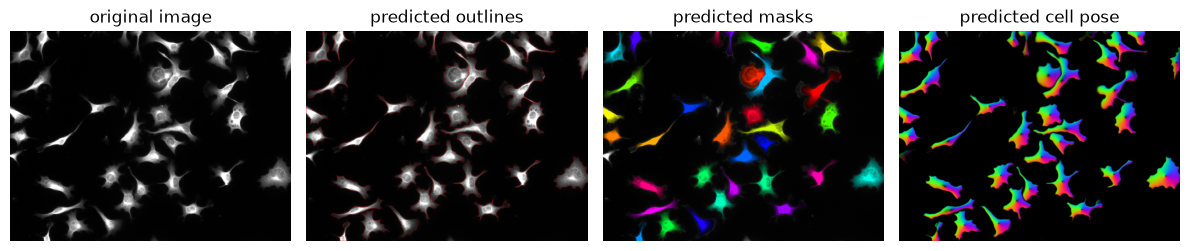

In [ ]:
fig = plt.figure(figsize=(12, 5))
plot.show_segmentation(fig, cp_image, masks, flows[0])
plt.tight_layout()
# Optional if you want to also save the figure
# plt.savefig(f"path/to/output/{Path(image_path).stem}_cp_output.png")
plt.show()

<div align="left"> <img src="https://raw.githubusercontent.com/bobiac/bobiac-book/main/_static/images/cellpose/cellpose_out.png" alt="Ilastik Logo" width="1000"></div>

<br>

To save the labelled masks as a .tif file, you can use the `Cellpose` `imsave` method from the `io` module (or e.g. the `tifffile` library if you add it to the dependencies):

In [ ]:
output_path = f"path/to/output/{Path(image_path).stem}_labels.tif"
io.imsave(output_path, masks)  # or tifffile.imwrite(output_path, masks)

To override the defaults, pass any parameter explicitly to `model.eval()` (see hidden cell above). For example, to adjust the segmentation quality parameters:

```python
masks, flows, styles = model.eval(
    cp_image,
    flow_threshold=0.2,
    cellprob_threshold=0.8,
    min_size=800,
)
```

## Run Cellpose on a Folder of Images

Now that we’ve seen how to run `Cellpose` on a single image, let’s scale up and apply it to a **folder of images**. This is useful when you have an entire experiment or dataset that you want to segment automatically.

The simplest way to do this is to just **loop through the images in the folder** and run `model.eval()` on each one. During each iteration, we can save the predicted masks to an output folder using the `imsave` method from the `Cellpose` `io` module (or the `tifffile` library if you add it to the dependencies).

<p class="alert alert alert-info">
    <strong>Note:</strong> If you work with small size images, you can also load them all at once (or in batches) into RAM and pass them as a list to <code>model.eval()</code>.
</p>

In [ ]:
# Path to the folder containing the images to segment
folder_path = Path("data/05_segmentation_cellpose")

# Get the sorted list of all .tif images in the folder
images_path = sorted(folder_path.glob("*.tif"))

# Initialize the model once before the loop
model_path = str(MODEL_DIR / "cpsam_v2")  # or "cpdino" / "cpdino-vitb" or "cpsam"
model = models.CellposeModel(pretrained_model=model_path, gpu=use_gpu)

# Run Cellpose on each image one by one
# NOTE: tqdm is used to show a progress bar, but you can remove it if you don't want it
for image_path in tqdm(images_path, desc="Processing images"):
    # Load the image
    image = io.imread(image_path)
    # Run Cellpose on the image
    masks, flows, styles = model.eval(image)
    # Save the segmentation results as a TIFF file
    output_path = folder_path / f"{image_path.stem}_labels.tif"
    io.imsave(output_path, masks)  # or tifffile.imwrite(output_path, masks)

## Bonus 1: GPU Optimization with `batch_size`

The simple loop above uses the default `batch_size=8`. This controls how many **256×256 tiles** are sent to the GPU per forward pass.

For each image, `Cellpose` splits it into overlapping tiles (10% overlap by default) and runs the network on them in groups of `batch_size`. Increasing `batch_size` reduces the number of GPU passes per image, which is faster, at the cost of more GPU memory.

**How many tiles does an image produce?**

The image is divided into 256×256 tiles with a 10% overlap between neighbors, and tiles are added to ensure the edges are fully covered. The total number of tiles grows with image size.

For example, a **1392×1040** image produces **5×7 = 35 tiles**:

| `batch_size` | GPU passes (35 tiles) |
|:---|:---|
| 8 (default) | 5 |
| 16 | 3 |
| 32 | 2 |
| 64 | 1 |

Increase `batch_size` until you hit out-of-memory errors, then back off one step.

<p class="alert alert alert-info">
    <strong>Note:</strong> The tile overlap can be adjusted using the <code>tile_overlap</code> parameters in <code>model.eval()</code>. The default is 0.1 (10%) overlap which is the value used during training, so it is recommended to keep it as default unless you have specific reasons to change it.
</p>

In [ ]:
# Path to the folder containing the images to segment
folder_path = Path("data/05_segmentation_cellpose")

# Get the sorted list of all .tif images in the folder
images_path = sorted(folder_path.glob("*.tif"))

# Increase batch_size to reduce GPU passes per image (uses more GPU memory)
batch_size = 8  # each pass sends batch_size tiles of 256×256 to the GPU
for image_path in tqdm(images_path, desc="Processing images"):
    image = io.imread(image_path)
    masks, flows, styles = model.eval(image, batch_size=batch_size)
    output_path = folder_path / f"{image_path.stem}_labels.tif"
    io.imsave(output_path, masks)

## Bonus 2: Cellpose 3D Segmentation

Running a 3D segmentation on a z-stack is not very different than running it on a 2D image, you just need to set `do_3D=True` and specify the `z_axis` and, if needed, `anisotropy` (see the `model.eval()` parameter dropdown above and the [3D Cellpose documentation](https://cellpose.readthedocs.io/en/latest/do3d.html) for more details).

The images we will use for this section can be downloaded from the <a href="https://bobiac.github.io/bobiac-book/_static/data/05_segmentation_cellpose_3d.zip" download> <i class="fas fa-download"></i> Cellpose 3D Dataset</a>.


### Load the 3D Image

In [ ]:
image_path = "../../../_static/images/cellpose/cell_cellpose_3d_crop.tif"
image = io.imread(image_path)  # or image = tifffile.imread(image_path)

print(image.shape)

For 3D segmentation, it is important to know the scale of the image in the XY and Z dimensions (e.g. from the metadata) so that we can set the `anisotropy` parameter correctly.

For this sample image, we have:
XY pixel size = 0.202 µm
Z step size = 0.5 µm

In [ ]:
scale_x = 0.202
scale_y = 0.202
scale_z = 0.5
anisotropy = scale_z / scale_x
print("Anisotropy:", anisotropy)

### Visualize the 3D Image

We can visualize the max intensity projection of the stack using `matplotlib`.

<p class="alert alert alert-info">
    <strong>💡 Note:</strong> If running the notebook locally (not on Google Colab), we can visualize the image using <code>ndv</code>. We can pass the <code>scales</code> parameter to set the scale for each axis (Z, Y, X) and correctly visualize the volume.
    <br><br>
    <code>import ndv</code>
    <br>
    <code># the shape of the image is (Z, Y, X) so we need to pass the scales in the same order</code>
    <br>
    <code>ndv.imshow(image, scales={0: scale_z, 1: scale_y, 2: scale_x})</code>
</p>

In [ ]:
# Create the max intensity projection image
max_p = np.max(image, axis=0)

# Visualize the max intensity projection image
plt.imshow(max_p, cmap="gray")
plt.axis("off")
plt.tight_layout()
plt.show()

# We can also visualise the reslice of the image acros the XZ dimension
plt.imshow(image[:, 110, :], cmap="gray")
plt.axis("off")
plt.tight_layout()
plt.show()

### Initialize the model

In [ ]:
model_path = str(MODEL_DIR / "cpsam_v2")  # or "cpdino" / "cpdino-vitb" or "cpsam"
model = models.CellposeModel(pretrained_model=model_path, gpu=use_gpu)

### Run Cellpose in 3D

In [ ]:
masks, flows, styles = model.eval(
    image, do_3D=True, z_axis=0, anisotropy=anisotropy, flow3D_smooth=1
)

### Visualize the results

We can visualize the results using the `show_segmentation` method from the Cellpose `plot` module (one slice at a time).

<p class="alert alert alert-info">
    <strong>💡 Note:</strong> If running the notebook locally (not on Google Colab), we can visualize the result labeled image using <code>ndv</code>. We can pass the <code>scales</code> parameter to set the scale for each axis (Z, Y, X) and correctly visualize the volume.
    <br><br>
    <code>import ndv</code>
    <br>
    <code># the shape of the image is (Z, Y, X) so we need to pass the scales in the same order</code>
    <br>
    <code>ndv.imshow(masks, scales={0: scale_z, 1: scale_y, 2: scale_x})</code>
</p>

In [ ]:
z = 18  # pick a slice
fig = plt.figure(figsize=(12, 5))
plot.show_segmentation(fig, image[z], masks[z], flows[0][z])
plt.tight_layout()
plt.show()

### Save the results

To save the labelled masks as a .tif file, you can use the `Cellpose` `imsave` method from the `io` module (or e.g. the `tifffile` library if you add it to the dependencies):

In [ ]:
output_path = f"path/to/output/{Path(image_path).stem}_3d_labels.tif"
io.imsave(output_path, masks)  # or tifffile.imwrite(output_path, masks)

## Bonus 3: Timelapse Batch Processing

When working with a timelapse, you cannot pass the raw stack array directly to `model.eval()`, `Cellpose` has no concept of timepoints and would misinterpret the time axis as channels or a z-stack.

The solution is to convert the stack into a **list of frames** using `list(stack)`, which slices along axis 0. The result depends on your axis order:

```python
# TCYX — axis 0 is time → list gives T frames of shape (C, Y, X)
stack.shape  # (10, 2, 512, 512)
list(stack)  # → [frame_0, ..., frame_9], each (2, 512, 512)
```

So we can pass the list of frames directly to `model.eval()`:

```python
frame_masks, frame_flows, frame_styles = model.eval(list(stack))
```

`frame_masks` will be a list of 2D label arrays, one per timepoint.


If the time axis is not the first one (e.g. CTYX), you need to transpose the stack first to get it into TCYX order before converting to a list:

```python
# CTYX — axis 0 is channel → wrong, need to transpose first
stack.shape  # (2, 10, 512, 512)
stack = stack.transpose(1, 0, 2, 3)  # CTYX → TCYX, then list(stack) works
```

Now that the stack is in TCYX order, you can pass it as a list to `model.eval()` and Cellpose will process each frame independently, returning one mask per frame.

```python
frame_masks, frame_flows, frame_styles = model.eval(list(stack))
```